# Drought Index Analysis

Computing SPI and SPEI to quantify drought severity, duration, and frequency across the 45 years in the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
bcolor = "darkslategrey"

df = pd.read_csv("../data/processed/mendoza_basin_monthly.csv", parse_dates=["time"], index_col="time")

print(f"Loaded {len(df)} months ({df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')})")
df.head()

Loaded 540 months (1980-01 to 2024-12)


,precip_mm,temp_c,pev_mm,runoff_mm,soil_moisture_0_7cm
time,,,,,
1980-01-01,63.820649,15.302368,183.912286,98.165597,0.191278
1980-02-01,93.886005,13.928650,148.222182,36.150087,0.191747
1980-03-01,66.787061,14.917786,132.601721,29.331790,0.162673
1980-04-01,162.947316,6.125000,59.435077,35.352784,0.201941
1980-05-01,115.186830,3.713196,39.293950,28.664771,0.218384


## SPI Computation

For the data, I want to calculate the SPI 3, 6, and 12 of the data. To make this simpler, I am going to make an SPI function. The steps for this will be as follows: 

- Rolling sum of precipitation over the starting month (so for SPI3 of August 2020, it would be the sum of June, July, and August 2020)  
- For each calendar month, do this and fit a gamma distribution to all historical values    
- Transform through gammaCDF, inverse normal CDF, and then you have the SPI value   


In [5]:
def compute_spi(precip_series, window):
    # Calculating the rolling sum of each calendar month
    precip_acc = precip_series.rolling(window=window, min_periods=window).sum()
    spi = pd.Series(index=precip_series.index, dtype=float)

    for month in range(1, 13):
        month_mask = precip_acc.index.month == month
        month_data = precip_acc[month_mask].dropna()

        # This is all to clean up the data, if there is too few data points it doesn't fit the gamma distribution, and if there are too few nonzero values same thing
        # This is also used to then later calculate what the non zero values are with the gamma distribution
        if len(month_data) < 10:
            continue
        nonzero = month_data[month_data > 0]
        prob_zero = 1.0 - len(nonzero) / len(month_data)
        if len(nonzero) < 5:
            continue
        
        # Fitting it nonzeros to a gamma distribution
        try:
            alpha, loc, beta = stats.gamma.fit(nonzero, floc=0)
        except Exception:
            continue

        for idx in month_data.index:
            val = precip_acc[idx]
            if np.isnan(val):
                continue
            
            # This is transforming it through gammaCDF
            if val <= 0:
                cdf_val = prob_zero / 2
            else:
                gamma_cdf = stats.gamma.cdf(val, alpha, loc=0, scale=beta)
                cdf_val = prob_zero + (1 - prob_zero) * gamma_cdf
            cdf_val = np.clip(cdf_val, 0.001, 0.999)

            # Transforms through inverse normal to give the spi value 
            spi[idx] = stats.norm.ppf(cdf_val)

    return spi

spi_3 = compute_spi(df["precip_mm"], window=3)
spi_6 = compute_spi(df["precip_mm"], window=6)
spi_12 = compute_spi(df["precip_mm"], window=12)

print("SPI Valid Computations:")
print(f"SPI3: {spi_3.notna().sum()} valid months")
print(f"SPI6: {spi_6.notna().sum()} valid months")
print(f"SPI12: {spi_12.notna().sum()} valid months")

# Checking that they were all standardised correctly
for name, spi in [("SPI3", spi_3), ("SPI6", spi_6), ("SPI12", spi_12)]:
    valid = spi.dropna()
    print(f"\n{name} mean: {valid.mean():.3f}, std: {valid.std():.3f}")

SPI Valid Computations:
SPI3: 538 valid months
SPI6: 535 valid months
SPI12: 529 valid months

SPI3 mean: -0.001, std: 1.001

SPI6 mean: -0.001, std: 1.001

SPI12 mean: -0.000, std: 1.001


## SPEI Computation

Same as SPI computation, the only difference is that for SPEI (standardised precipitation evapotranspiration index) you use the water balance value (P - PET) instead of precipitation. Also due to the nature of SPEI (it can be negative) I use a normal distribution and not a gamma distribution. This is so that I can show months where while rainfall is normal, very high evaporation demands can cause an abnormally dry month.

In [6]:
def compute_spei(precip_series, pet_series, window):
    water_balance = precip_series - pet_series
    
    wb_acc = water_balance.rolling(window=window, min_periods=window).sum()
    spei = pd.Series(index=precip_series.index, dtype=float)

    for month in range(1, 13):
        month_mask = wb_acc.index.month == month
        month_data = wb_acc[month_mask].dropna()

        if len(month_data) < 10:
            continue

        mu = month_data.mean()
        sigma = month_data.std()

        if sigma == 0:
            continue

        for idx in month_data.index:
            val = wb_acc[idx]
            if not np.isnan(val):
                spei[idx] = (val - mu) / sigma
    
    return spei

spei_3 = compute_spei(df["precip_mm"], df["pev_mm"], window=3)
spei_6 = compute_spei(df["precip_mm"], df["pev_mm"], window=6)

print("SPEI Valid Computations:")
print(f"SPEI3: {spei_3.notna().sum()} valid months")
print(f"SPEI6: {spei_6.notna().sum()} valid months")

# Checking that they were all standardised correctly
for name, spei in [("SPEI3", spei_3), ("SPEI6", spei_6)]:
    valid = spei.dropna()
    print(f"\n{name} mean: {valid.mean():.3f}, std: {valid.std():.3f}")

SPEI Valid Computations:
SPEI3: 538 valid months
SPEI6: 535 valid months

SPEI3 mean: -0.000, std: 0.990

SPEI6 mean: 0.000, std: 0.990


## SPI Time Series

Typical drought visualisation. The red bars below zero indicate drier than normal conditions. The SPI are shown by dashed lines with the following thresholds:

- Moderate (<-1.0)  
- Severe (<-1.5)    
- Extreme (<-2.0)

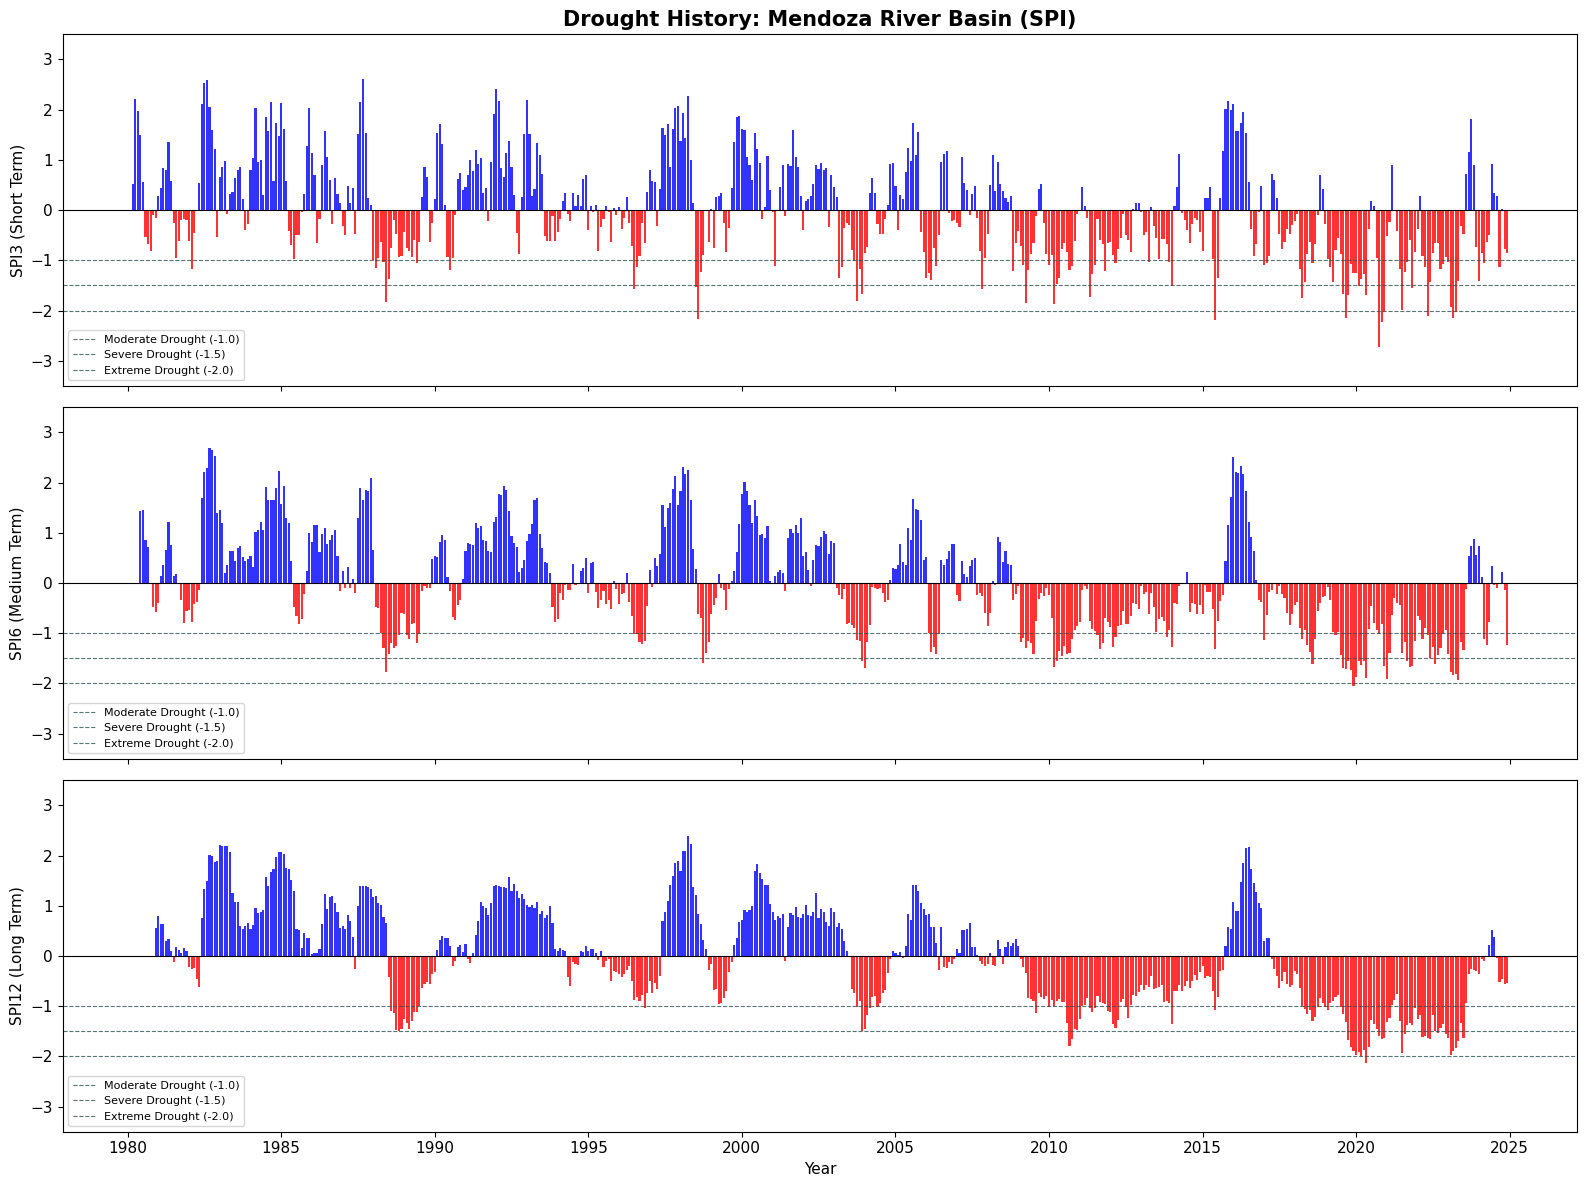

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, spi, title in zip(axes, [spi_3, spi_6, spi_12], ["SPI3 (Short Term)", "SPI6 (Medium Term)", "SPI12 (Long Term)"]):
    valid = spi.dropna()
    colors = ["red" if v < 0 else "blue" for v in valid.values]
    ax.bar(valid.index, valid.values, color=colors, width=25, alpha=0.8)

    ax.axhline(y=-1.0, color=bcolor, linestyle="--", linewidth=0.8, alpha=0.8, label="Moderate Drought (-1.0)")
    ax.axhline(y=-1.5, color=bcolor, linestyle="--", linewidth=0.8, alpha=0.8, label="Severe Drought (-1.5)")
    ax.axhline(y=-2.0, color=bcolor, linestyle="--", linewidth=0.8, alpha=0.8, label="Extreme Drought (-2.0)")
    ax.axhline(y=0, color="black", linewidth=0.8)

    ax.set_ylabel(title)
    ax.set_ylim(-3.5, 3.5)
    ax.legend(loc="lower left", fontsize=8)

axes[0].set_title("Drought History: Mendoza River Basin (SPI)", fontsize=15, fontweight="bold")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/figures/spi_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## SPI vs SPEI comparison

I compare precipitation (SPI) vs water balance (SPEI) drought indices. Divergence between the two indicates periods where temperature/evaporative demand played a more of a role in water stress beyond just rainfall deficits.

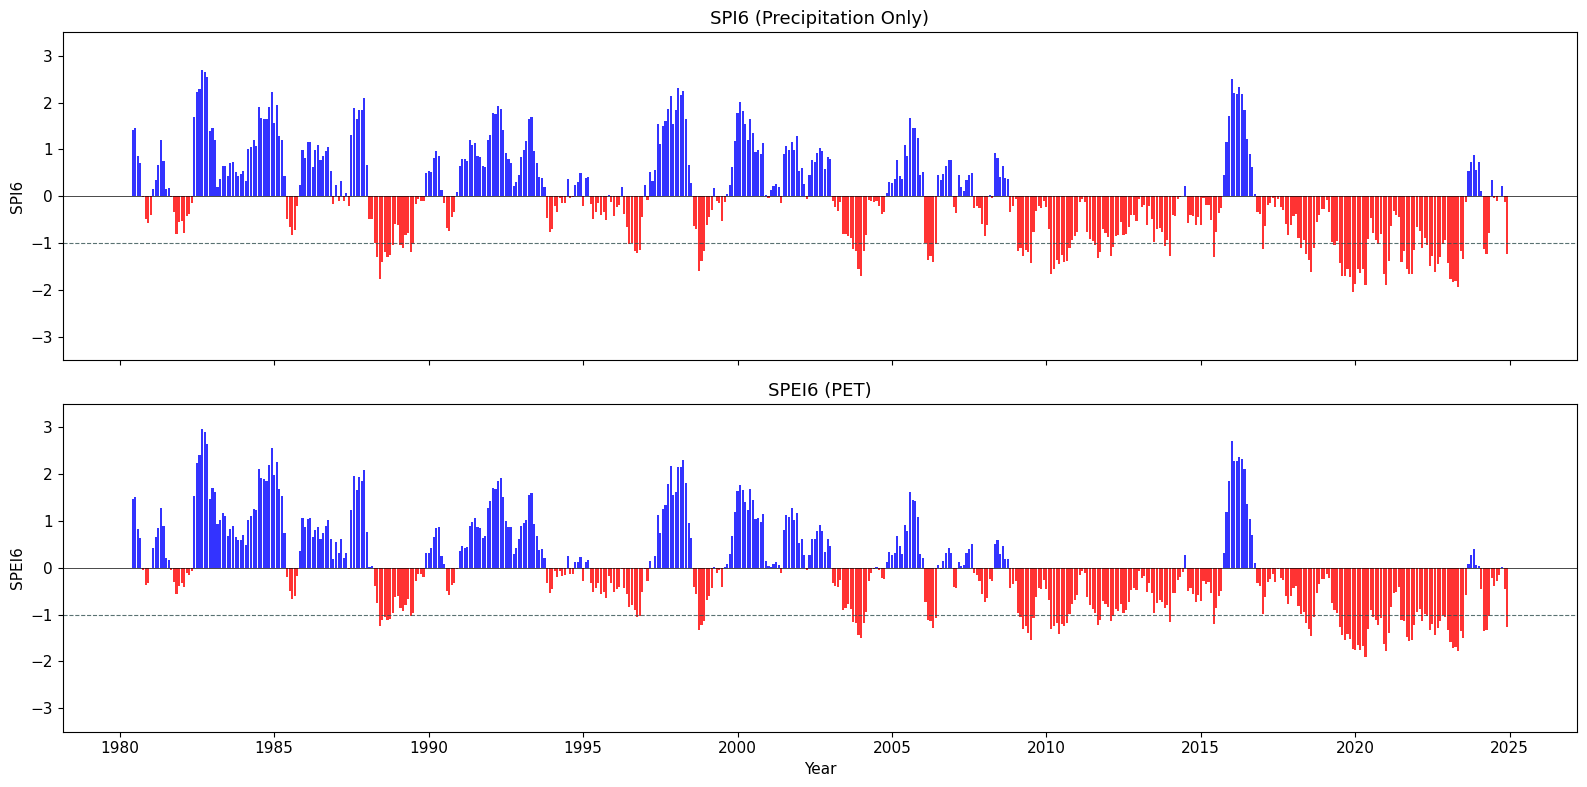

SPI6 vs SPEI6 correlation: 0.981


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# SPI6
valid = spi_6.dropna()
colors = ["red" if v < 0 else "blue" for v in valid.values]
axes[0].bar(valid.index, valid.values, color=colors, width=25, alpha=0.8)
axes[0].axhline(y=-1.0, color=bcolor, linestyle="--", linewidth=0.8, alpha=0.8)
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].set_ylabel("SPI6")
axes[0].set_title("SPI6 (Precipitation Only)", fontsize=13)
axes[0].set_ylim(-3.5, 3.5)

# SPEI6
valid = spei_6.dropna()
colors = ["red" if v < 0 else "blue" for v in valid.values]
axes[1].bar(valid.index, valid.values, color=colors, width=25, alpha=0.8)
axes[1].axhline(y=-1.0, color=bcolor, linestyle="--", linewidth=0.8, alpha=0.8)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("SPEI6")
axes[1].set_title("SPEI6 (PET)", fontsize=13)
axes[1].set_ylim(-3.5, 3.5)
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/figures/spi_vs_spei.png", dpi=150, bbox_inches="tight")
plt.show()

# Comparison
both_valid = pd.DataFrame({"SPI6": spi_6, "SPEI6": spei_6}).dropna()
correlation = both_valid.corr().iloc[0, 1]
print(f"SPI6 vs SPEI6 correlation: {correlation:.3f}")